<a href="https://colab.research.google.com/github/neetagt/Data-Analysis-with-Python/blob/main/PageViewTimeSeriesVisualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Import data (Make sure to parse dates. Consider setting index column to 'date'.)

df = pd.read_csv('fcc-forum-pageviews.csv', index_col = 'date', parse_dates = ['date'])

# Clean data
top_percentile = df.value.quantile(0.975)
bottom_percentile = df.value.quantile(0.025)
df = df[((df.value > bottom_percentile) & (df.value < top_percentile))]

def draw_line_plot():
    # Draw line plot
    fig, ax = plt.subplots(figsize=(15, 5))
    sns.lineplot(data=df, x=df.index, y='value', ax=ax, linewidth=1)

    ax.set_title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
    ax.set_xlabel('Date')
    ax.set_ylabel('Page Views')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.xaxis.set_major_locator(plt.MaxNLocator(10))
    ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    fig.savefig('line_plot.png')
    return fig

def draw_bar_plot():
    # Prepare data
    df_bar = df.copy()
    df_bar['Year'] = df_bar.index.year
    df_bar['Month'] = df_bar.index.month

    # Group and reshape
    df_grouped = df_bar.groupby(['Year', 'Month'])['value'].mean().unstack()

    # Plot
    fig = df_grouped.plot(kind='bar', figsize=(14, 7)).figure
    plt.xlabel('Years')
    plt.ylabel('Average Page Views')

    # Month labels
    month_names = ["January", "February", "March", "April", "May", "June",
                   "July", "August", "September", "October", "November", "December"]
    plt.legend(month_names, title='Month', fontsize=10)

    plt.tight_layout()

    # Save and return
    fig.savefig('bar_plot.png')
    return fig


def draw_box_plot():
    # Prepare data
    df_box = df.copy()
    df_box['Year'] = df_box.index.year
    df_box['Month'] = df_box.index.strftime('%b')  # Abbreviated month names
    df_box['Month_Num'] = df_box.index.month       # For sorting months later

    # Sort by Month_Num to ensure Jan-Dec order
    df_box = df_box.sort_values('Month_Num')

    # Draw plots
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))

    sns.boxplot(x='Year', y='value', data=df_box, ax=axes[0])
    axes[0].set_title('Year-wise Box Plot (Trend)')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Page Views')

    sns.boxplot(x='Month', y='value', data=df_box, ax=axes[1])
    axes[1].set_title('Month-wise Box Plot (Seasonality)')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Page Views')

    plt.tight_layout()
    fig.savefig('box_plot.png')
    return fig

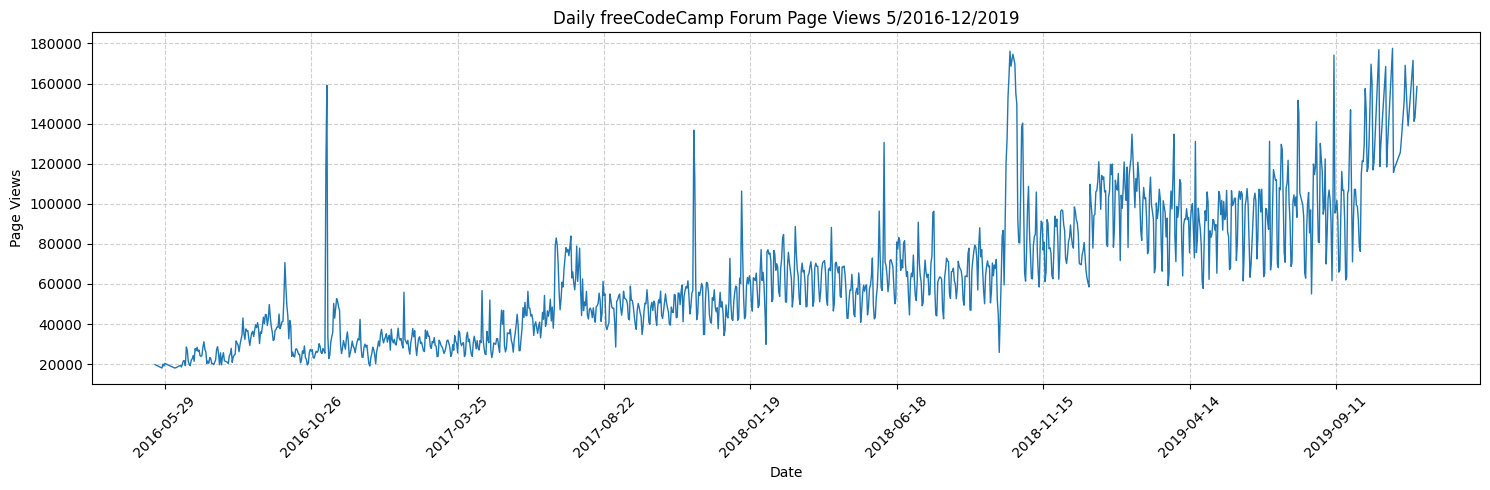

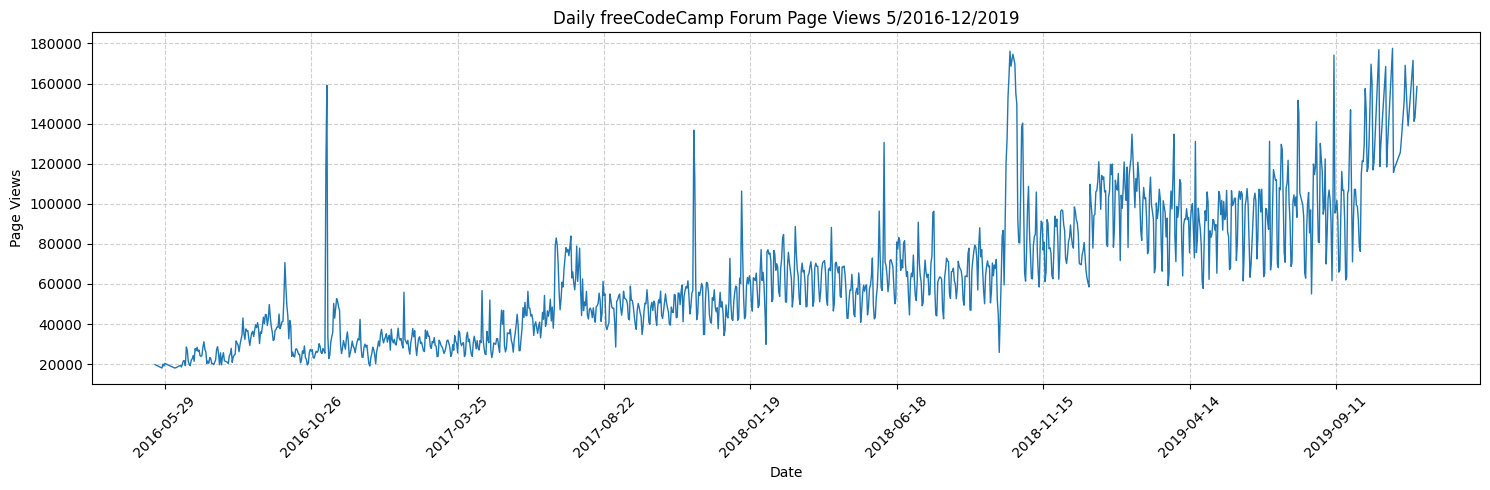

In [38]:
draw_line_plot()

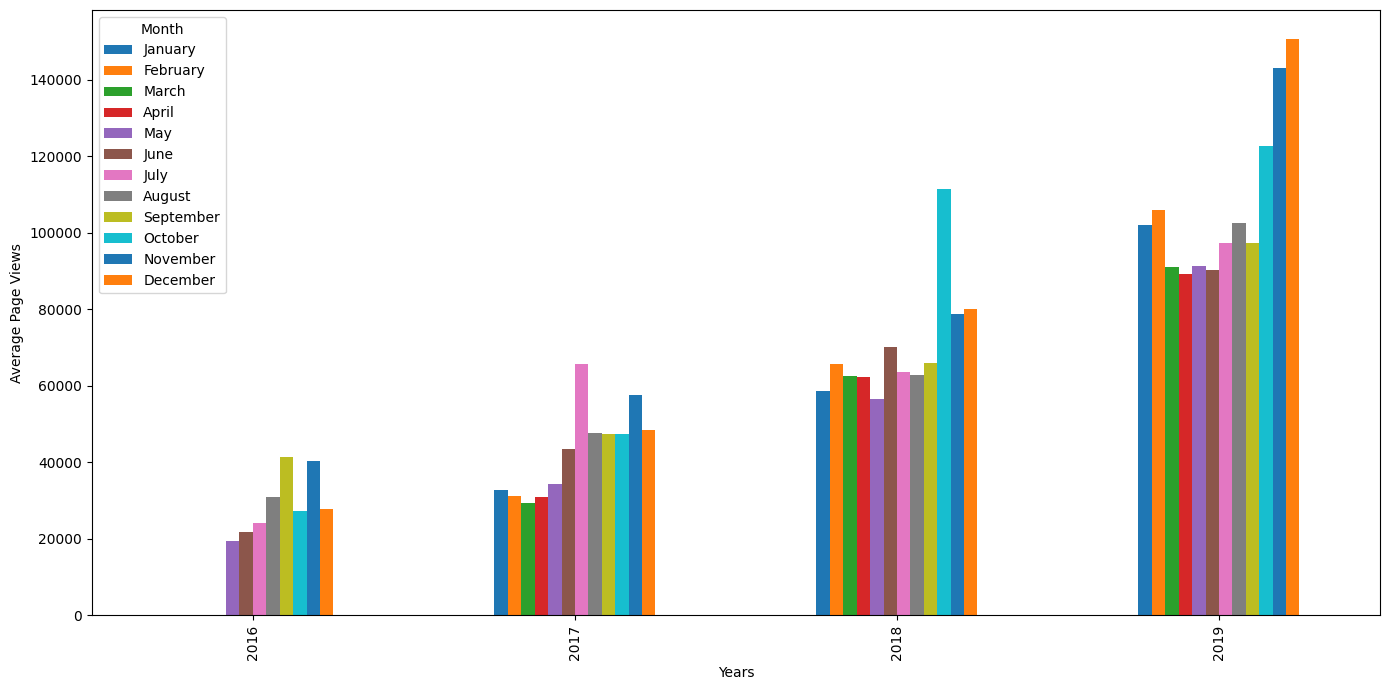

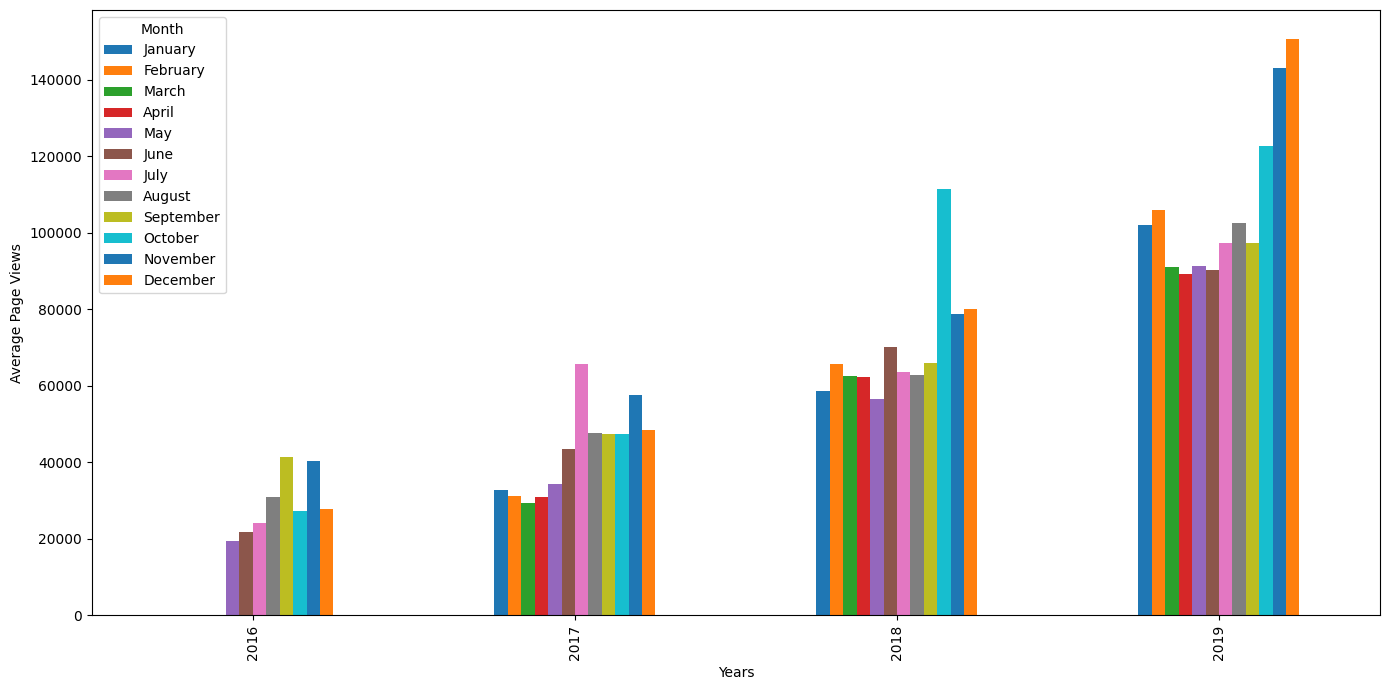

In [39]:
draw_bar_plot()

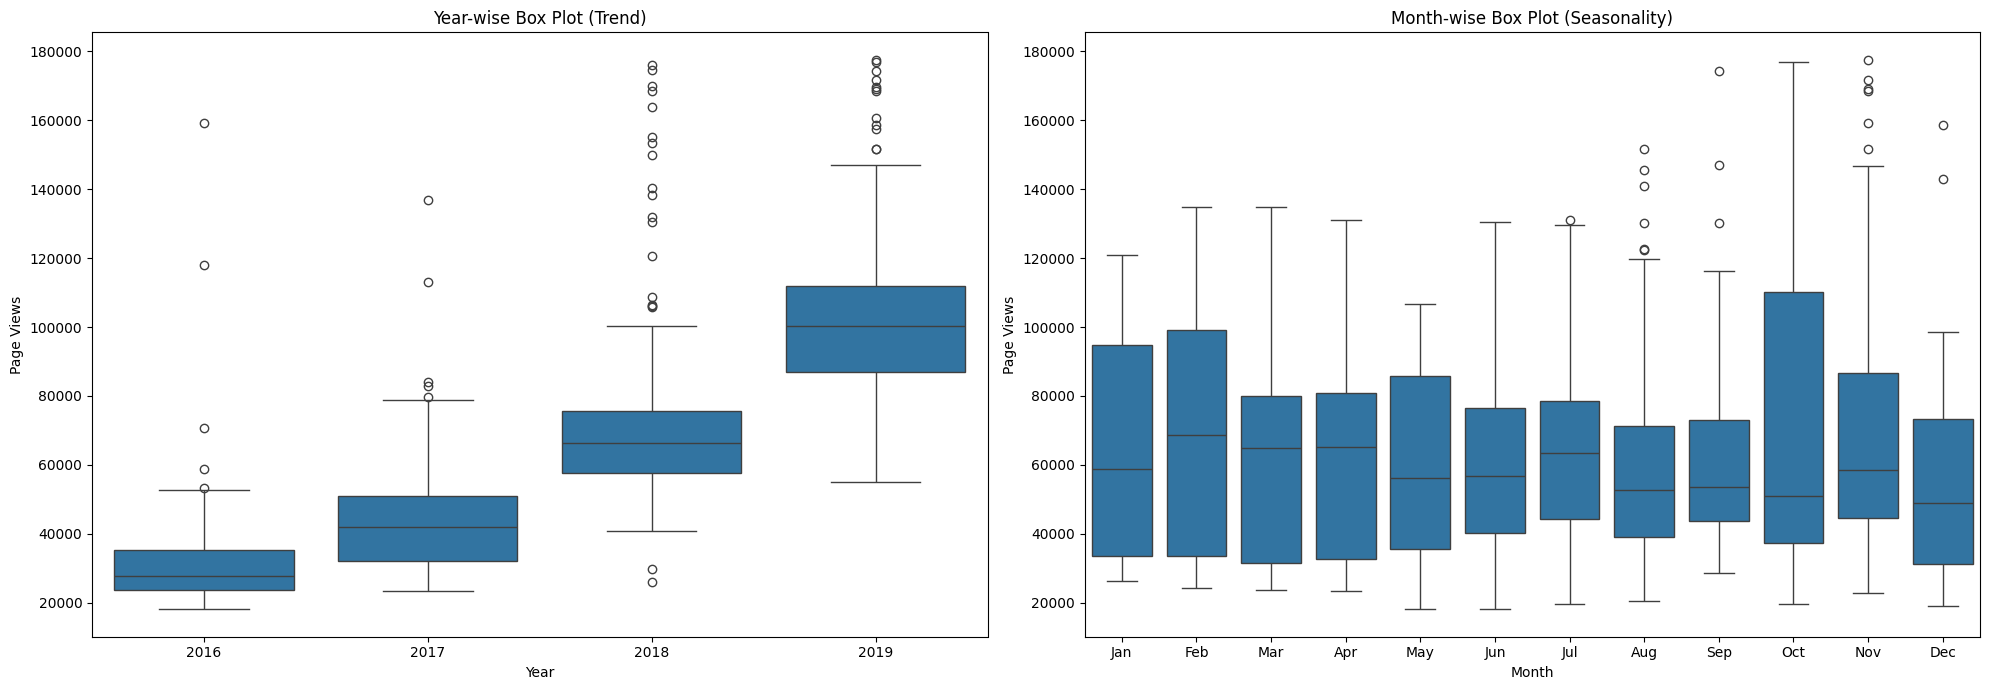

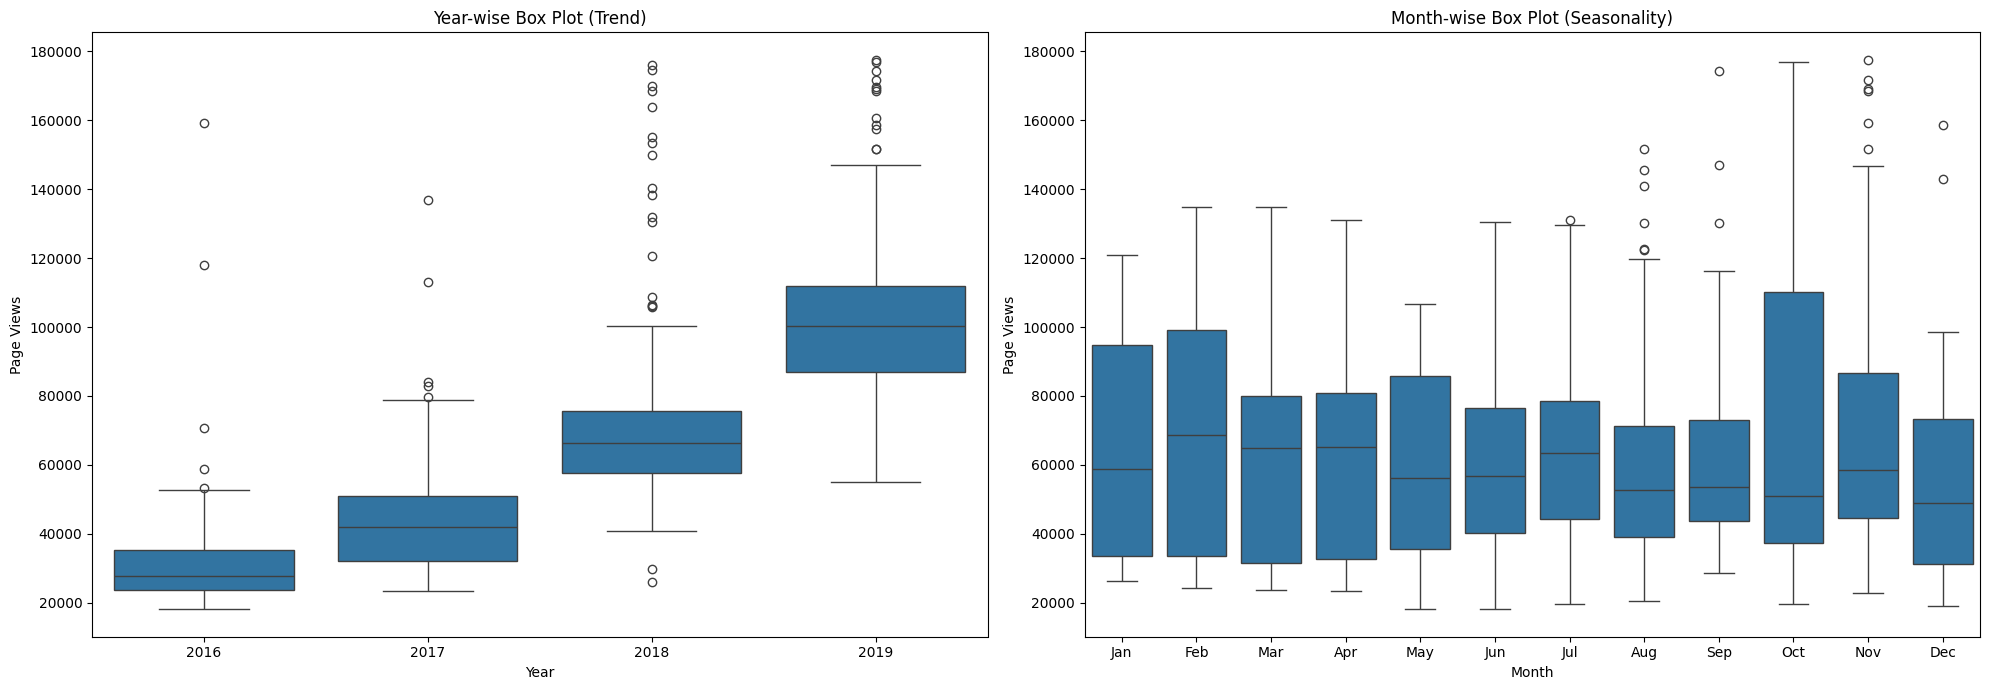

In [40]:
draw_box_plot()

In [41]:
df

,value
date,
2016-05-19,19736
2016-05-26,18060
2016-05-27,19997
2016-05-28,19044
2016-05-29,20325
...,...
2019-11-24,138875
2019-11-29,171584
2019-11-30,141161
